# Zero-shot water forecasting with open weather data

**AEMON-J / DSOS "Hacking Limnology" 2026 — Day 2: Climate Data**
Workshop: *How to access petabytes of weather forecasts from your laptop*
(Jake Zwart, USGS · Thiago Nascimento, EAWAG · Alden Keefe Sampson, Dynamical)

You will generate a short-range forecast of a **water variable** — streamflow,
stream temperature, lake temperature, or **your own uploaded timeseries** — using
[Chronos-2](https://huggingface.co/amazon/chronos-2), a zero-shot time-series
foundation model, conditioned on open ensemble weather forecasts from
[dynamical.org](https://dynamical.org). At the end you **submit** your forecast
for an eventual global evaluation.

> **Run it as-is first.** With no edits, this notebook reproduces a working
> forecast for the Delaware River at Montague, NJ (USGS-01438500). Then change the
> single **config block** in Section 1 to forecast *your* site.

#### Why forecast streamflow at Montague?
Under the 1954 U.S. Supreme Court decree (today's Flexible Flow Management Program),
New York City must release water from its Delaware Basin reservoirs (Cannonsville,
Pepacton, Neversink) to keep a **minimum flow of 1,750 CFS (~49.6 m³/s, 24-hr
average)** at
Montague, NJ — protecting downstream ecology, recreation, and water supply. Because
water takes ~2–3 days to travel from the reservoirs, releases are planned days
ahead, so a skillful few-day streamflow forecast directly informs how much to release
and when. That decision-relevant, lead-time-sensitive setting is what this workshop
demonstrates.

### How to run
- **Google Colab (recommended):** click the badge in the README, or open this
  file via `colab.research.google.com/github/jzwart/hacking_limno_2026_forecast/blob/main/notebooks/forecast_workshop.ipynb`.
  No install needed beyond the first cell. A Google account helps for submission
  but is not required to run.
- **Locally with `uv`** (no Google account; best for *unstable* connections or
  repeated runs — you download the stack and model weights once and cache them,
  instead of re-fetching whenever a Colab session recycles): see
  `docs/local_setup.md`.


## 0. Setup

Installs the forecasting stack. On Colab this takes ~1–2 min.

*Optional:* set a Hugging Face token as the Colab secret `HF_TOKEN` to avoid
occasional rate limits when downloading model weights (Chronos-2 is public, so this
is not required).

> ⚠️ **On Colab the runtime restarts once, automatically, after this cell.** The
> install changes `numpy`, and Colab has already imported the old one — the
> restart loads a clean environment. This is expected: **re-run from the top**
> after it restarts (the install is cached, so it will be quick), then continue.
>
> On **Linux/Colab** we install the **CPU build of PyTorch** first, from PyTorch's
> CPU wheel index, so the heavier installs below don't pull the large CUDA build
> (a single-site forecast runs fine on CPU). On **macOS/Windows** PyPI's torch is
> already CPU-only, so we install it from PyPI directly. If you have a capable GPU
> locally, see `docs/local_setup.md` for the GPU path.

In [1]:
import os
import shutil
import subprocess
import sys
import platform

# A disk sentinel survives the kernel restart (kernel *state* does not), so we
# install + restart exactly once even under "Run all" / repeated top-to-bottom.
# It is written ONLY after a fully successful install, so a failure re-runs clean.
# The version suffix invalidates a stale sentinel when the install logic below
# changes: Colab's "Restart runtime" keeps the VM disk (and this /tmp file), so
# without a bump an old, broken install would keep being skipped. Bump it whenever
# the install steps change.
_SENTINEL = "/tmp/.forecast_workshop_installed_v4"

# When launched via `uv run --with jupyter jupyter lab`, the kernel runs in an
# ephemeral uv environment that has NO pip — `python -m pip install` fails with
# "No module named pip". Detect uv (it sets $UV and $VIRTUAL_ENV) and shell out to
# `uv pip install --python <this-interpreter>` instead, so packages land in the
# same env the kernel imports from. On Colab there is no uv, so we use pip.
_UV = os.environ.get("UV") or shutil.which("uv")
_USE_UV = bool(_UV and os.environ.get("VIRTUAL_ENV"))


def _pip(*pkgs, extra_args=()):
    """Install packages as a subprocess so we can check the exit code and see output."""
    if _USE_UV:
        cmd = [_UV, "pip", "install", "--python", sys.executable, *extra_args, *pkgs]
    else:
        cmd = [sys.executable, "-m", "pip", "install", *extra_args, *pkgs]
    # Let the subprocess inherit the parent's real stdout/stderr file descriptors
    # (the default) rather than passing sys.stdout: in Colab/Jupyter sys.stdout is
    # a fake stream with no file descriptor, so subprocess's fileno() call raises
    # "UnsupportedOperation: fileno". Inheriting also streams pip output live.
    result = subprocess.run(cmd)
    if result.returncode != 0:
        raise RuntimeError(
            "Dependency install failed (see output above). Nothing was cached, so "
            "re-run this cell after resolving the offending package."
        )


if not os.path.exists(_SENTINEL):
    # 1) CPU PyTorch first, so the heavier installs below don't pull the large CUDA
    #    build (a single-site forecast runs fine on CPU). The CPU wheel index only
    #    serves Linux/Windows wheels, and is only *needed* on Linux (where plain
    #    PyPI torch would pull the CUDA build). On macOS/Windows PyPI's torch is
    #    already CPU-only, so install from PyPI there — the CPU index has no macOS
    #    wheels and is prone to timeouts.
    if platform.system() == "Linux":
        _pip("torch<2.10", extra_args=("--index-url", "https://download.pytorch.org/whl/cpu"))
    else:
        _pip("torch<2.10")
    # 2) numpy pinned so the heavier installs below don't half-upgrade it (the
    #    classic "cannot import name '_center' from numpy._core.umath" crash).
    _pip("numpy>=1.26,<2.1")
    # 3) the forecasting stack. `truststore` lets Python use the OS trust store
    #    for TLS, so requests works behind TLS-inspecting corporate/institutional
    #    proxies (e.g. USGS) that inject a self-signed root CA — otherwise every
    #    https call fails with CERTIFICATE_VERIFY_FAILED. Harmless elsewhere.
    #    chronos-forecasting[extras] pulls transformers; installing CPU torch first
    #    (above) keeps it from dragging in a CUDA torch build.
    _pip("truststore", "icechunk", "pystac", "rioxarray", "cartopy", "geopandas",
         "chronos-forecasting[extras]>=2.2",
         "git+https://github.com/kratzert/RivRetrieve-Python.git")

    # 4) Remove torchvision AND torchaudio. Colab preinstalls CUDA builds of both,
    #    and pip may leave them (or reinstall mismatched builds via chronos extras)
    #    beside our CPU torch. That ABI mismatch breaks their C++ ops against CPU torch
    #    — torchvision fails to register torchvision::nms ("operator torchvision::nms
    #    does not exist") and torchaudio fails to load its .so ("undefined symbol:
    #    torch_library_impl") — either of which cascades into transformers' lazy import
    #    ("Could not import module 'PreTrainedModel'"). Chronos-2 CPU inference uses
    #    neither, so uninstalling them makes transformers skip those paths entirely —
    #    far more robust than trying to keep the ABIs matched. Ignore the exit code if
    #    a package is already gone.
    if _USE_UV:
        subprocess.run([_UV, "pip", "uninstall", "--python", sys.executable,
                        "torchvision", "torchaudio"])
    else:
        subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y",
                        "torchvision", "torchaudio"])

    open(_SENTINEL, "w").close()

    # On Colab, restart the runtime once so the freshly installed numpy is the
    # one that gets imported. Re-run from the top after the restart.
    try:
        import google.colab  # noqa: F401
        import IPython
        print("Install complete — restarting the Colab runtime. "
              "Re-run from the top when it comes back.")
        IPython.Application.instance().kernel.do_shutdown(restart=True)
    except ImportError:
        print("Local run — no restart needed; continue to the next cell.")
else:
    print("Dependencies already installed — skipping install and restart.")

Dependencies already installed — skipping install and restart.


In [2]:
import json
import warnings

# Route Python's TLS through the OS trust store so https calls (dynamical.org,
# mghydro.com, Hugging Face) succeed behind TLS-inspecting proxies that inject a
# self-signed root CA — the OS already trusts it, but requests' bundled certifi
# store does not. No-op if truststore isn't installed (e.g. a plain Colab run).
try:
    import truststore
    truststore.inject_into_ssl()
except ImportError:
    pass

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import icechunk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pystac
import requests
import rioxarray  # noqa: F401  registers the .rio accessor
import xarray as xr
from shapely.geometry import shape

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams.update(
    {"font.size": 14, "axes.titlesize": 16, "axes.labelsize": 14, "legend.fontsize": 12}
)

IN_COLAB = "google.colab" in str(get_ipython())  # noqa: F821
print("Running in Colab" if IN_COLAB else "Running locally")

Running in Colab


## 1. Choose your target  ⬅️ **the only block most people edit**

Pick a **preset** (published data pulled automatically) or **upload a CSV** of
your own timeseries. Everything downstream reads from this block.

### Option A — a published preset
Set `TARGET_MODE = "published"` and choose a `PRESET` key below. The default
`delaware_streamflow` (Delaware River at Montague, NJ) reproduces the reference
forecast. Commented presets show how to point at other gauges / sources.

### Option B — bring your own data
Set `TARGET_MODE = "upload"` **and edit the `UPLOAD_META` cell** below (your site's
latitude/longitude, variable, and units) — that second cell is part of the config
too, not just Section 1's banner. Then run the upload cell. Your CSV needs two
columns: a date/timestamp column and a numeric value column (see
`docs/example_timeseries.csv` for the shape). Gaps are fine — Chronos-2 forecasts
from an incomplete history (we explore this in `appendix_model_deep_dive.ipynb`).

In [3]:
# ============================ EDIT HERE ============================
TARGET_MODE = "upload"          # "published"  or  "upload"
PRESET = "delaware_streamflow"     # used only when TARGET_MODE == "published"

# Forecast issue date (t0). Defaults to today; set an explicit date to reproduce a
# past run, e.g. INIT_TIME = pd.Timestamp("2026-01-08").
INIT_TIME = pd.Timestamp.today().normalize()
FORECAST_DAYS = 10                       # horizon

# --- weather covariates fed to Chronos-2 (add / remove freely) ---
# Each key is a dynamical.org variable name; the model conditions the forecast on
# these as future-known inputs (past analysis + ensemble forecast). Comment a line
# out to drop that covariate, or add one to condition on more weather. `scale`
# converts the dataset's native units (precip is a surface flux -> mm/day); `label`
# is only used for axis titles. Whatever you list here must exist in BOTH the GEFS
# and IFS ENS datasets (see the STAC catalog note in §4). Forecasting with an empty
# {} is allowed — Chronos-2 then runs on the target history alone.
COVARIATES = {
    "temperature_2m":        {"scale": 1.0,      "label": "air temperature [K]"},
    "precipitation_surface": {"scale": 86_400.0, "label": "precipitation [mm/day]"},
}

# --- your details, baked into the submission file (see Section 7) ---
PARTICIPANT = {
    "name": "Nitha Fathima Nazir",            # e.g. "Ada Lovelace"
    "affiliation": "",
    "email": "nithafathimanazir@gmail.com",
    "orcid": "https://orcid.org/0009-0004-6001-1518",           # optional
    "coauthor_optin": True,  # True = consent to co-authorship on a global-eval output for Hacking Limnology
}
# ==================================================================

# Published presets. Each describes WHERE the target obs come from and HOW to
# locate the contributing area for basin-averaged weather.
#   location_mode: "delineate" (point -> upstream basin, for rivers)
#                  "buffer"    (point -> square box, for lakes/points)
PRESETS = {
    # --- default: Delaware River at Montague, NJ (USGS-01438500) ---
    "delaware_streamflow": {
        "variable": "streamflow",
        "units": "m3/s",
        "source": "rivretrieve:USAFetcher",
        "gauge_id": "01438500",          # USGS site number
        "rr_variable": "discharge_daily_mean",
        "lat": 41.3123, "lon": -74.7960,
        "location_mode": "delineate",
    },
    # --- backup: Thames at Kingston, UK (reproduces the original reference) ---
    # "thames_streamflow": {
    #     "variable": "streamflow",
    #     "units": "m3/s",
    #     "source": "rivretrieve:UKEAFetcher",
    #     "gauge_id": "8496ce69-482c-406a-a2f0-ac418ef8f099",
    #     "rr_variable": "discharge_daily_mean",
    #     "lat": 51.4155, "lon": -0.3076,
    #     "location_mode": "delineate",
    # },
    # --- lake surface temperature: easiest path is CSV upload ---------
    #     There is no single global published API bundled here, so for lakes
    #     use TARGET_MODE = "upload" with your own LSWT timeseries, and set a
    #     point below via UPLOAD_META (buffer box for weather). See
    #     docs/data_sources.md for candidate sources (e.g. satellite LSWT).
}


In [16]:
UPLOAD_META = {
    "variable": "discharge_m3_s",
    "units": "m3/sec",
    "site_name": "Mahanadi",
    "lat": 20.655,             # ← CHANGE THIS: your site latitude  (weather covariates come from here)
    "lon": 83.7275,             # ← CHANGE THIS: your site longitude
    "location_mode": "delineate",  # "buffer" (point+box) or "delineate" (river point)
    "buffer_deg": 0.25,          # half-width of weather box when location_mode=="buffer"
}

Saving river_discharge_manual_daily_cwc_od_2001_2025.csv to river_discharge_manual_daily_cwc_od_2001_2025.csv
Loaded 3600 daily values (2001-01-01 to 2025-12-12), 5512 gaps.


In [17]:
# Resolve the active target config from whichever mode is selected.
if TARGET_MODE == "published":
    cfg = dict(PRESETS[PRESET])
elif TARGET_MODE == "upload":
    cfg = dict(UPLOAD_META)
else:
    raise ValueError("TARGET_MODE must be 'published' or 'upload'")

# Insert before model fitting to fill missing daily gaps
obs_filled = uploaded_obs.interpolate(method='time').bfill().ffill()

TARGET_LAT, TARGET_LON = cfg["lat"], cfg["lon"]
VARIABLE = cfg["variable"]
UNITS = cfg.get("units", "")

# EFI Ecological Forecasting Initiative standard identifiers for the export in §7.
# PROJECT_ID names the challenge/collection; DURATION is the ISO 8601 timestep of the
# forecast (P1D = daily). These land in every row of the standardized forecast file.
PROJECT_ID = "hacking_limno_2026"
DURATION = "P1D"

# Forecast in log space? Streamflow is strictly positive and heavily right-skewed
# (low baseflow most days, occasional large floods), so Chronos-2 forecasts it better
# on a log scale — the transform compresses the peaks and keeps predictions positive.
# We use log1p/expm1, so exact zeros are fine. NOT for variables that go negative
# (e.g. temperature in degC), so this auto-enables only for streamflow; override by
# setting LOG_TARGET explicitly. `cfg.get("log_target")` lets a preset force it.
LOG_TARGET = cfg.get("log_target", VARIABLE == "streamflow")
print(f"Target: {VARIABLE} [{UNITS}] at ({TARGET_LAT}, {TARGET_LON}) "
      f"via {TARGET_MODE}; horizon {FORECAST_DAYS} d from {INIT_TIME.date()}"
      f"{'; forecasting in log space' if LOG_TARGET else ''}")


Target: discharge_m3_s [m3/sec] at (20.655, 83.7275) via upload; horizon 10 d from 2026-08-11


## 2. Define the contributing area

Weather covariates are averaged over an area around your site. For **rivers**
(`location_mode="delineate"`) we fetch the upstream drainage polygon from the
[Global Watersheds API](https://mghydro.com/watersheds/). For **lakes / points**
(`location_mode="buffer"`) we use a square box around the point. Advanced users:
`appendix_zonal_stats.ipynb` shows area-weighted zonal stats with `xvec`.

/usr/local/lib/python3.12/dist-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(0.5, 1.0, 'Contributing area for weather covariates (delineate)')

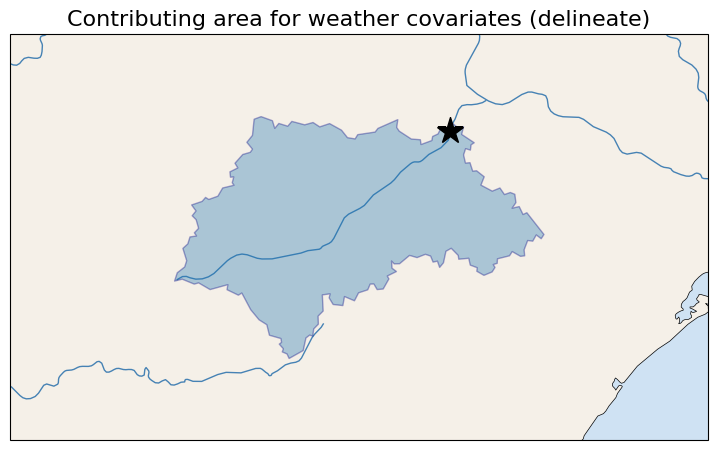

In [18]:
from shapely.geometry import box

location_mode = cfg.get("location_mode", "buffer")

if location_mode == "delineate":
    resp = requests.get(
        "https://mghydro.com/app/watershed_api",
        params={"lat": TARGET_LAT, "lng": TARGET_LON, "precision": "low"},
    ).json()
    area = shape(resp["features"][0]["geometry"]).simplify(0.01)
else:
    b = cfg.get("buffer_deg", 0.25)
    area = box(TARGET_LON - b, TARGET_LAT - b, TARGET_LON + b, TARGET_LAT + b)

minx, miny, maxx, maxy = area.bounds

fig, ax = plt.subplots(figsize=(9, 6), subplot_kw={"projection": ccrs.PlateCarree()})
ax.set_extent([minx - 1, maxx + 1, miny - 0.5, maxy + 0.5])
ax.add_feature(cfeature.LAND, facecolor="#f5f0e8")
ax.add_feature(cfeature.OCEAN, facecolor="#cfe2f3")
ax.add_feature(cfeature.COASTLINE, lw=0.5)
ax.add_feature(cfeature.RIVERS, color="steelblue")
ax.add_geometries([area], crs=ccrs.PlateCarree(),
                  facecolor="tab:blue", edgecolor="navy", alpha=0.35)
ax.plot(TARGET_LON, TARGET_LAT, "k*", markersize=20, transform=ccrs.PlateCarree())
ax.set_title(f"Contributing area for weather covariates ({location_mode})")


## 3. Observed target timeseries

For a published preset we pull observations through
[RivRetrieve](https://github.com/kratzert/RivRetrieve-Python), a unified
interface to global streamflow data (swap the fetcher to change country). For an
upload, we use the series you loaded in Section 1.

Text(0.5, 1.0, 'Observed discharge_m3_s')

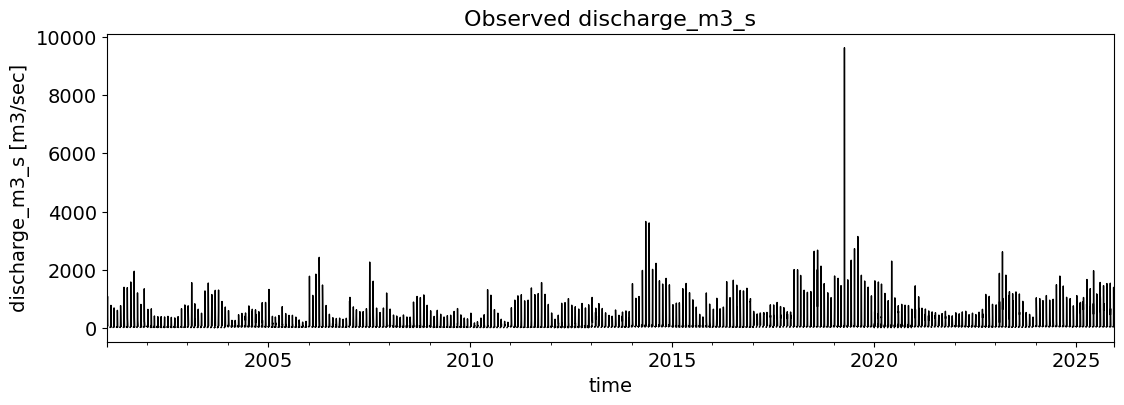

In [19]:

if TARGET_MODE == "published" and cfg["source"].startswith("rivretrieve:"):
    import rivretrieve
    fetcher_name = cfg["source"].split(":", 1)[1]
    Fetcher = getattr(rivretrieve, fetcher_name)
    obs = Fetcher().get_data(
        gauge_id=cfg["gauge_id"],
        variable=cfg["rr_variable"],
        start_date="2010-01-01",
        end_date=str(pd.Timestamp.today().date()),
    )[cfg["rr_variable"]]
    obs = pd.to_numeric(obs, errors="coerce")  # RivRetrieve may return strings
    obs.name = VARIABLE
elif TARGET_MODE == "upload":
    obs = uploaded_obs
else:
    raise ValueError(f"Unsupported source: {cfg.get('source')}")

obs.index.name = "time"
fig, ax = plt.subplots(figsize=(13, 4))
obs.plot(ax=ax, color="black", lw=1)
ax.set_ylabel(f"{VARIABLE} [{UNITS}]")
ax.set_title(f"Observed {VARIABLE}")


## 4. Weather covariates from dynamical.org

We average the covariates you chose in §1 (`COVARIATES`; by default air temperature
and precipitation) over the contributing area:
past values from the **NOAA GEFS analysis** (the history the model sees) and
**10-day ensemble forecasts** from both **NOAA GEFS** (31 members) and
**ECMWF IFS ENS** (51 members). Each ensemble member becomes one plausible future.

> 💡 We open each dataset straight from the dynamical.org **STAC catalog** at
> `https://stac.dynamical.org/catalog.json`: read the collection's `icechunk-https`
> asset, open its [Icechunk](https://icechunk.io) repo, and hand the store to
> `xarray.open_zarr`. The catalog is designed to be AI-friendly — point an LLM at it
> to discover more datasets.

In [20]:
# How much past history to feed the model. ~6 years of daily values is plenty of
# seasonal context for Chronos-2 while keeping the dynamical.org pull modest; lower
# this on a slow connection (see docs/local_setup.md).
HISTORY_DAYS = 365 * 6
history_window = slice(INIT_TIME - pd.Timedelta(days=HISTORY_DAYS),
                       INIT_TIME - pd.Timedelta(days=1))
print(f"History window: {history_window.start.date()} -> {history_window.stop.date()} "
      f"({HISTORY_DAYS} days)")


History window: 2020-08-12 -> 2026-08-10 (2190 days)


In [21]:
# The covariate variable names + unit scaling come straight from the COVARIATES
# config in §1, so adding/removing a covariate there flows through everything below.
COV_NAMES = list(COVARIATES)


def basin_daily(ds, time_dim):
    """Clip to the contributing area, average over space, resample to daily.

    Each covariate is rescaled to physical units per its COVARIATES `scale`
    (e.g. precipitation surface-flux -> mm/day).
    """
    out = (
        ds[COV_NAMES]
        .sel(latitude=slice(maxy + 0.5, miny - 0.5), longitude=slice(minx - 0.5, maxx + 0.5))
        .rio.clip([area], crs="EPSG:4326")
        .mean(dim=("latitude", "longitude"))
        .resample({time_dim: "1D"}).mean()
    )
    for name, spec in COVARIATES.items():
        out[name] *= spec["scale"]
    return out.load()


# Open a dynamical.org dataset via its STAC entry: read the collection's
# `icechunk-https` asset, open the Icechunk repo read-only, and hand the store to
# xarray. Cached so each dataset's catalog + repo handshake happens only once.
_STAC = pystac.Catalog.from_file("https://stac.dynamical.org/catalog.json")


def open_dynamical(dataset_id):
    asset = _STAC.get_child(dataset_id).assets["icechunk-https"]
    repo = icechunk.Repository.open(icechunk.http_storage(asset.href))
    session = repo.readonly_session("main")
    return xr.open_zarr(session.store, chunks=None)


def forecast_meteo(dataset_id):
    return basin_daily(
        open_dynamical(dataset_id)
        .sel(init_time=INIT_TIME, lead_time=slice("0h", f"{FORECAST_DAYS}d"))
        .swap_dims({"lead_time": "valid_time"}),
        "valid_time",
    ).isel(valid_time=slice(0, FORECAST_DAYS))


analysis_meteo = basin_daily(
    open_dynamical("noaa-gefs-analysis").sel(time=slice(history_window.start, None)),
    "time",
)
gefs_fc_basin = forecast_meteo("noaa-gefs-forecast-35-day")
ifs_fc_basin = forecast_meteo("ecmwf-ifs-ens-forecast-15-day-0-25-degree")

history_df = (
    pd.concat(
        {VARIABLE: obs,
         **{name: analysis_meteo[name].to_pandas() for name in COV_NAMES}},
        axis=1,
    )
    .loc[history_window]
    .reset_index()
    .rename(columns={"time": "timestamp"})
)
# Keep target gaps (NaN) — the foundation models handle them — but require every
# covariate to be present (no-op if COVARIATES is empty).
history_df = history_df.dropna(subset=COV_NAMES)
print(f"History rows: {len(history_df)}, target gaps: {history_df[VARIABLE].isna().sum()}")


History rows: 2190, target gaps: 1421


## 5. Run the forecast with Chronos-2

Chronos-2 receives the past target + past weather, plus a future weather trace per
ensemble member, and returns a **quantile forecast** per member — same history,
different future weather.

The forecast ensemble combines **two** sources of uncertainty: the spread across
weather members *and* Chronos-2's own predictive quantiles. We keep every quantile
(not just the median), so with 51 weather members × 3 quantiles the ensemble has
153 traces. Weather members alone barely diverge at short lead times — most of the
honest day-1 spread comes from the model's quantiles.

- **Chronos-2** — `predict_df(context_df, future_df=..., quantile_levels=...)`;
  covariates are passed as known-future values in `future_df`, and it returns one
  column per requested quantile. We keep each quantile as its own trace labeled
  `<member>_q<level>`.

When `LOG_TARGET` is set (auto-enabled for streamflow in §1), the target is fed to
the model in `log1p` space and the forecast quantiles are inverted with `expm1`
before anything is plotted or saved — so the CSV is always in physical units. Flow
is strictly positive and right-skewed, and forecasting the log tends to track the
rising limb of an event better while keeping predictions non-negative.

> This runs on CPU by default (no GPU needed); `device` is auto-selected below.

In [22]:
def _future_long(future_basin):
    """dynamical forecast DataArray -> long DataFrame [member, timestamp, *covariates]."""
    return (
        future_basin.to_dataframe().reset_index()
        .rename(columns={"valid_time": "timestamp", "ensemble_member": "member"})
        [["member", "timestamp", *COV_NAMES]]
        .astype({"member": str})
    )


In [23]:
import torch
from chronos import Chronos2Pipeline

_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
chronos = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map=_DEVICE)

# Predictive quantile levels to request from the model. Kept as their own traces
# (not collapsed to the median) so the ensemble carries the model's own uncertainty.
_Q = [0.1, 0.5, 0.9]

# The covariates chosen in §1 (COV_NAMES) are FUTURE-KNOWN: we have both the analysis
# over the history window and a forecast over the horizon, so they ride along in
# `future_df` (which spans the forecast horizon per series) via _future_long.


def run_chronos2(future_basin):
    """Chronos-2 traces per ensemble member. Returns DataFrame [time x <member>_q<level>].

    Builds one series per weather member: a shared target history (with that
    member's history covariates) plus that member's future-known weather covariates.
    The forecast ensemble combines BOTH sources of uncertainty — the spread across
    weather members AND Chronos-2's own predictive quantiles — so we keep every
    quantile, not just the median. With 51 weather members and 3 quantiles that
    yields 153 traces, labeled e.g. "12_q0.9".
    """
    fut = _future_long(future_basin)
    members = fut["member"].unique()

    # Context: replicate the shared target history once per member, tagged by member
    # id. Forecast in log space when LOG_TARGET is set (see §1); log1p keeps exact
    # zeros finite and preserves NaNs, and we invert with expm1 on the forecast
    # below. Only the target is transformed — covariates keep their physical units.
    hist = history_df.copy()
    if LOG_TARGET:
        hist[VARIABLE] = np.log1p(hist[VARIABLE])
    context = pd.concat(
        [hist.assign(member=m) for m in members], ignore_index=True
    )

    pred = chronos.predict_df(
        context,
        future_df=fut,
        prediction_length=FORECAST_DAYS,
        quantile_levels=_Q,
        id_column="member",
        timestamp_column="timestamp",
        target=VARIABLE,
    )

    # predict_df returns one row per (member, timestamp) with a column per quantile
    # level (named "0.1", "0.5", ...). Reshape to [timestamp x <member>_q<level>].
    out = {}
    valid_time = None
    for member, g in pred.groupby("member"):
        g = g.sort_values("timestamp")
        for q_level in _Q:
            vals = g[str(q_level)].to_numpy(dtype="float32")
            if LOG_TARGET:
                vals = np.expm1(vals)                            # back to physical units
            out[f"{member}_q{q_level}"] = vals
        valid_time = g["timestamp"].to_numpy()
    return pd.DataFrame(out, index=pd.DatetimeIndex(valid_time, name="timestamp"))


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

In [24]:
MODELS = {"Chronos-2": run_chronos2}
COVARIATE_SOURCES = {"GEFS": gefs_fc_basin, "IFS ENS": ifs_fc_basin}

# predictions[model][covariate_source] -> DataFrame [valid_time x member]
predictions = {}
for model_name, runner in MODELS.items():
    predictions[model_name] = {}
    for cov_name, fc_basin in COVARIATE_SOURCES.items():
        print(f"Running {model_name} with {cov_name} covariates ...")
        predictions[model_name][cov_name] = runner(fc_basin)
print("Done.")


Running Chronos-2 with GEFS covariates ...
Running Chronos-2 with IFS ENS covariates ...
Done.


## 6. Forecast plots

Ensemble spread (thin lines) and ensemble mean (thick) for each weather source,
over the recent observed record.

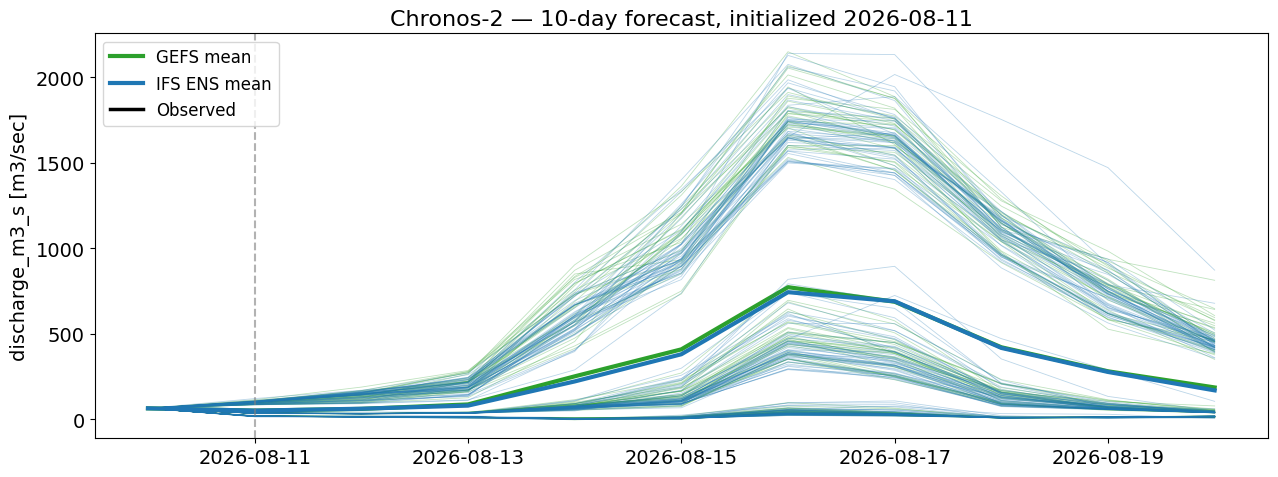

In [25]:
PLOT_WINDOW = slice(INIT_TIME - pd.Timedelta(days=30),
                    INIT_TIME + pd.Timedelta(days=FORECAST_DAYS))

# The model's target ends at INIT_TIME - 1 day (see the history_window). Prepend
# that last observed value to each forecast trace so the fan visibly emanates from
# the observed line instead of floating below it — standard forecast-plot practice.
_ANCHOR_TIME = INIT_TIME - pd.Timedelta(days=1)
_ANCHOR_VALUE = obs.loc[:_ANCHOR_TIME].dropna().iloc[-1]


def _with_anchor(pred):
    """Prepend the last observed (time, value) row to every column of a forecast frame."""
    anchor = pd.DataFrame(_ANCHOR_VALUE, index=[_ANCHOR_TIME], columns=pred.columns)
    return pd.concat([anchor, pred])


def plot_traces(ax, pred, color, label):
    pred = _with_anchor(pred)
    ax.plot(pred.index, pred.values, color=color, lw=0.6, alpha=0.30)
    ax.plot(pred.index, pred.mean(axis=1), color=color, lw=3, label=f"{label} mean")


def plot_obs_and_init(ax):
    o = obs.loc[PLOT_WINDOW]
    ax.plot(o.index, o.values, color="black", lw=2.5, label="Observed")
    ax.axvline(INIT_TIME, color="gray", ls="--", alpha=0.6)
    ax.set_ylabel(f"{VARIABLE} [{UNITS}]")
    ax.legend(loc="upper left")


fig, axes = plt.subplots(len(MODELS), 1, figsize=(13, 5 * len(MODELS)), sharex=True)
axes = np.atleast_1d(axes)
cov_colors = {"GEFS": "tab:green", "IFS ENS": "tab:blue"}
for ax, (model_name, by_cov) in zip(axes, predictions.items()):
    for cov_name, pred in by_cov.items():
        plot_traces(ax, pred, cov_colors[cov_name], cov_name)
    plot_obs_and_init(ax)
    ax.set_title(f"{model_name} — {FORECAST_DAYS}-day forecast, initialized {INIT_TIME.date()}")
fig.tight_layout()


Text(0.5, 1.0, 'Chronos-2 forecast — GEFS vs IFS ENS weather (ensemble mean, 10–90%)')

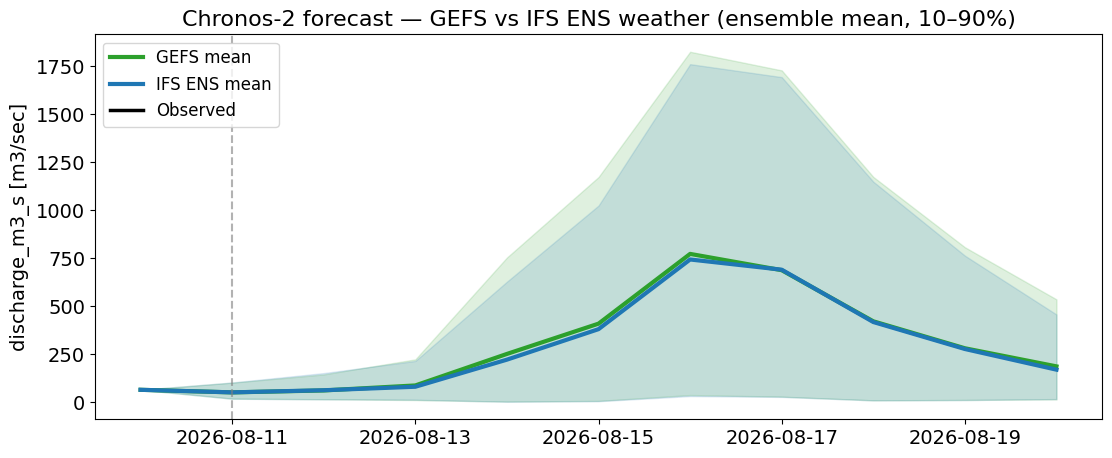

In [26]:
# Weather-source comparison: Chronos-2 ensemble mean and 10-90% spread per source.
fig, ax = plt.subplots(figsize=(13, 5))
by_cov = predictions["Chronos-2"]
for cov_name, pred in by_cov.items():
    pred = _with_anchor(pred)
    ax.plot(pred.index, pred.mean(axis=1), color=cov_colors[cov_name],
            lw=3, label=f"{cov_name} mean")
    ax.fill_between(pred.index, pred.quantile(0.1, axis=1), pred.quantile(0.9, axis=1),
                    color=cov_colors[cov_name], alpha=0.15)
plot_obs_and_init(ax)
ax.set_title("Chronos-2 forecast — GEFS vs IFS ENS weather (ensemble mean, 10–90%)")


## 7. Export & submit your forecast

We write a **standardized forecast file** in the [Ecological Forecasting Initiative
(EFI) standard](https://projects.ecoforecast.org/neon4cast-docs/Submission-Instructions.html)
— the same long format used by the NEON / USGS forecasting challenges — plus a
**metadata sidecar**, using values already in scope. Then submit both through the
workshop Google Form (which also handles the optional co-authorship consent).

The EFI columns are `project_id, model_id, datetime, reference_datetime, duration,
site_id, variable, family, parameter, prediction`. We report `family="ensemble"`:
each forecast trace is one ensemble member (`parameter` = its integer index), so the
full weather-member × Chronos-2-quantile spread is preserved without fitting a
distribution. Each weather source becomes its own `model_id`.

**Submit here:** https://forms.gle/DMqsNGiZtV1wjYP56  ·  details in `docs/submission.md`.

In [27]:
# EFI-standard long format: one row per (model_id, ensemble member, datetime).
# Each forecast trace (weather_member x chronos2_quantile) is one ensemble member; we
# renumber the traces of each model_id to a contiguous integer `parameter` index.
slug = (PRESET if TARGET_MODE == "published" else VARIABLE).replace(" ", "_")
ref_dt = INIT_TIME.strftime("%Y-%m-%d")


def _model_id(model_name, cov_name):
    """Stable EFI model_id, e.g. 'chronos2_gefs', from a model + weather source."""
    norm = lambda s: s.lower().replace("-", "").replace(" ", "_")
    return f"{norm(model_name)}_{norm(cov_name)}"


rows = []
for model_name, by_cov in predictions.items():
    for cov_name, pred in by_cov.items():
        # Map each trace column to a 1-based ensemble member index for this model_id.
        member_index = {col: i + 1 for i, col in enumerate(pred.columns)}
        long = (
            pred.reset_index()
            .melt(id_vars="timestamp", var_name="_trace", value_name="prediction")
        )
        long["parameter"] = long["_trace"].map(member_index)
        long["model_id"] = _model_id(model_name, cov_name)
        long["datetime"] = long["timestamp"].dt.strftime("%Y-%m-%d")
        rows.append(long.drop(columns=["timestamp", "_trace"]))

forecast_long = pd.concat(rows, ignore_index=True)
forecast_long["project_id"] = PROJECT_ID
forecast_long["reference_datetime"] = ref_dt
forecast_long["duration"] = DURATION
forecast_long["site_id"] = slug
forecast_long["variable"] = VARIABLE
forecast_long["family"] = "ensemble"

# Order columns to the EFI standard.
forecast_long = forecast_long[[
    "project_id", "model_id", "datetime", "reference_datetime", "duration",
    "site_id", "variable", "family", "parameter", "prediction",
]]

stem = f"forecast_{slug}_{INIT_TIME.date()}"
forecast_long.to_csv(f"{stem}.csv", index=False)

metadata = {
    "participant": PARTICIPANT,
    "standard": "EFI",
    "project_id": PROJECT_ID,
    "site_id": slug,
    "variable": VARIABLE,
    "units": UNITS,
    "duration": DURATION,
    "family": "ensemble",
    "location": {"lat": TARGET_LAT, "lon": TARGET_LON,
                 "location_mode": cfg.get("location_mode")},
    "reference_datetime": ref_dt,
    "forecast_days": FORECAST_DAYS,
    "model_ids": sorted(forecast_long["model_id"].unique().tolist()),
    "models": list(MODELS),
    "covariate_sources": list(COVARIATE_SOURCES),
    "covariates": list(COVARIATES),
    # Each ensemble member (`parameter`) is a "<weather_member>_q<quantile>" trace:
    # the ensemble carries both weather-member spread and Chronos-2's predictive quantiles.
    "ensemble_encoding": "weather_member x chronos2_quantile",
    "quantiles": _Q,
    "n_members_per_model": int(forecast_long.groupby("model_id")["parameter"].nunique().max()),
    # Predictions in the CSV are already in physical units; this records whether the
    # model forecast in log1p space internally (predictions inverted with expm1).
    "log_target": bool(LOG_TARGET),
    "target_mode": TARGET_MODE,
    "preset": PRESET if TARGET_MODE == "published" else None,
    "coauthor_optin": PARTICIPANT["coauthor_optin"],
    "license": "CC-BY-4.0",
}
with open(f"{stem}.metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"Wrote {stem}.csv ({len(forecast_long)} rows) and {stem}.metadata.json")
if not PARTICIPANT["name"]:
    print("⚠️  PARTICIPANT['name'] is empty — fill in Section 1 before submitting.")


Wrote forecast_discharge_m3_s_2026-08-11.csv (2460 rows) and forecast_discharge_m3_s_2026-08-11.metadata.json


In [28]:
# On Colab, download the two files so you can attach them to the Google Form.
if IN_COLAB:
    from google.colab import files
    files.download(f"{stem}.csv")
    files.download(f"{stem}.metadata.json")
else:
    print(f"Files written to the working directory: {stem}.csv, {stem}.metadata.json")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Where to go next
- `appendix_zonal_stats.ipynb` — area-weighted covariate extraction with `xvec`.
- `appendix_model_deep_dive.ipynb` — how Chronos-2 behaves with gaps in the target
  history, and how covariates change the forecast.
- Swap the fetcher / gauge in Section 1 to forecast a different river; see
  `docs/data_sources.md` for options.